# Noise Robustness Plots

Plots each reconstruction quality metric (MSE, SSIM, PSNR, Correlation, LPIPS) as a function of sinogram noise standard deviation, comparing ResUNet-a, ConvNeXt, Pix2Pix, and FBP.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

## Data

Noise levels ordered by ascending std. `None` SNR denotes the noise-free baseline.

In [6]:
snr_db = [None, 45, 40, 35, 30, 27.5, 25]
noise_std = [
    0.0,
    0.00022630586245154174,
    0.00040298238786357207,
    0.0007156094560889979,
    0.0012727337980277414,
    0.0016993619829077198,
    0.0022639671795840356,
]

resunet_a = {
    "MSE":         [0.001022, 0.001023, 0.001059, 0.001546, 0.003117, 0.004531, 0.006541],
    "SSIM":        [0.843480, 0.842692, 0.835933, 0.779766, 0.626156, 0.525084, 0.411984],
    "PSNR":        [31.199307, 31.197254, 30.990014, 28.943839, 25.652274, 23.918931, 22.153451],
    "Correlation": [0.945946, 0.945826, 0.943446, 0.913105, 0.827648, 0.759380, 0.668332],
    "LPIPS":       [0.284266, 0.284026, 0.291486, 0.354980, 0.465122, 0.512150, 0.552153],
}

convnext = {
    "MSE":         [0.000204, 0.000209, 0.000230, 0.000281, 0.000378, 0.000489, 0.000808],
    "SSIM":        [0.946245, 0.945566, 0.941808, 0.932793, 0.912309, 0.884581, 0.813188],
    "PSNR":        [37.853601, 37.767045, 37.199388, 36.132075, 34.635766, 33.381028, 31.070472],
    "Correlation": [0.988163, 0.987878, 0.986410, 0.983179, 0.977249, 0.970194, 0.950710],
    "LPIPS":       [0.166927, 0.165310, 0.167330, 0.175484, 0.199687, 0.233361, 0.294697],
}

pix2pix = {
    "MSE":         [0.000237, 0.000240, 0.000251, 0.000295, 0.000432, 0.000531, 0.000633],
    "SSIM":        [0.942308, 0.941614, 0.939594, 0.931614, 0.909254, 0.893211, 0.862952],
    "PSNR":        [37.172041, 37.109862, 36.861655, 35.941374, 34.009354, 33.056871, 32.305062],
    "Correlation": [0.986194, 0.986018, 0.985329, 0.982370, 0.973487, 0.967747, 0.962931],
    "LPIPS":       [0.171848, 0.171141, 0.171180, 0.175753, 0.191815, 0.206606, 0.249184],
}

fbp = {
    "MSE":         [0.000137, 0.000155, 0.000197, 0.000326, 0.000735, 0.001204, 0.002031],
    "SSIM":        [0.9609, 0.9474, 0.9197, 0.8447, 0.6838, 0.5724, 0.4559],
    "PSNR":        [38.8248, 38.2104, 37.1426, 34.8988, 31.3422, 29.1971, 26.9246],
    "Correlation": [0.9938, 0.9922, 0.9890, 0.9797, 0.9536, 0.9275, 0.8880],
    "LPIPS":       [0.084643, 0.146632, 0.220211, 0.317921, 0.435671, 0.495162, 0.551946],
}

models = {
    "ResUNet-a": resunet_a,
    "ConvNeXt":  convnext,
    "Pix2Pix":   pix2pix,
    "FBP":       fbp,
}

styles = {
    "ResUNet-a": {"color": "#4C72B0", "marker": "o"},
    "ConvNeXt":  {"color": "#DD8452", "marker": "s"},
    "Pix2Pix":   {"color": "#55A868", "marker": "^"},
    "FBP":       {"color": "#7f7f7f", "marker": "D"},
}

## Plots

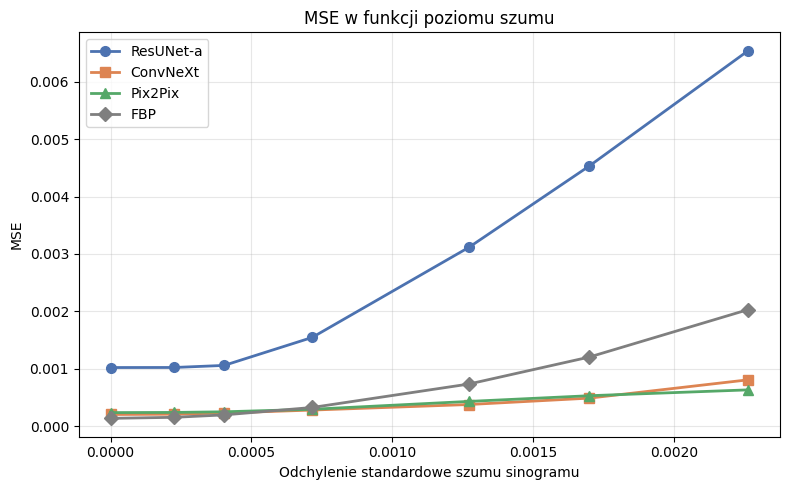

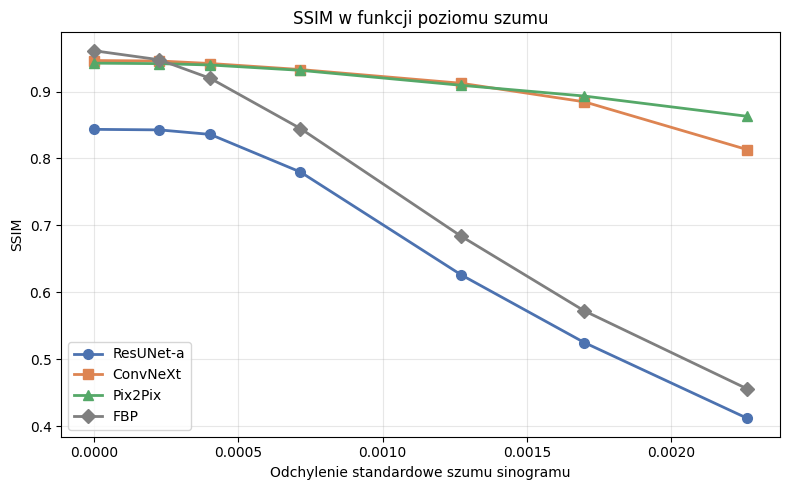

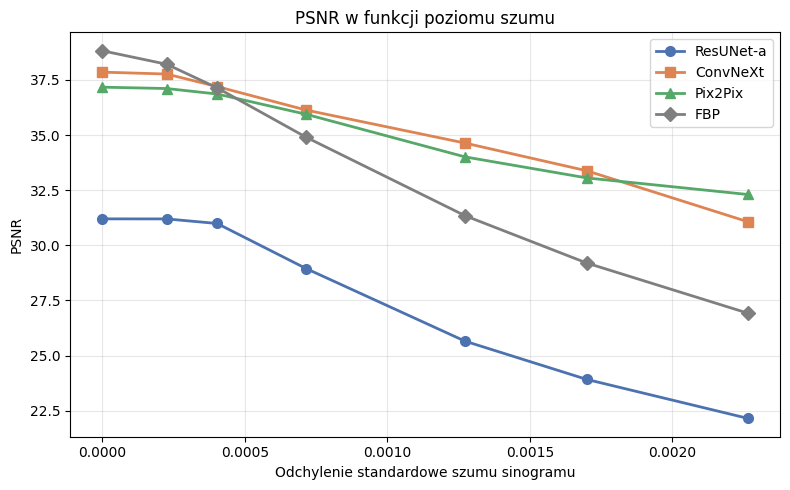

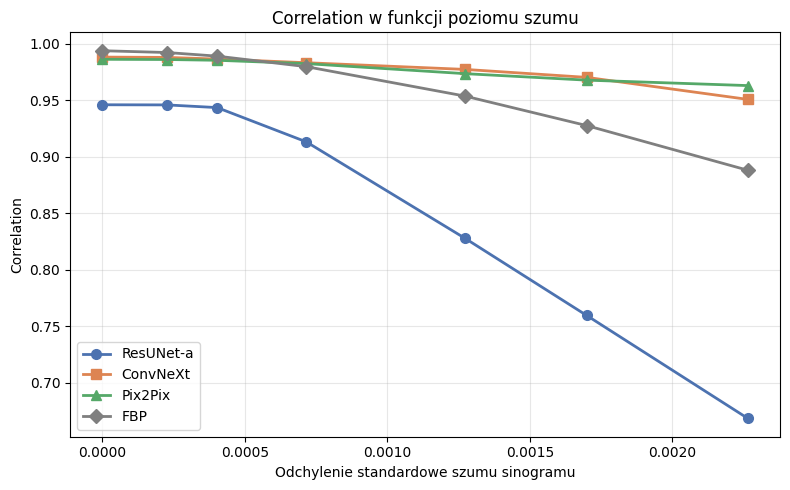

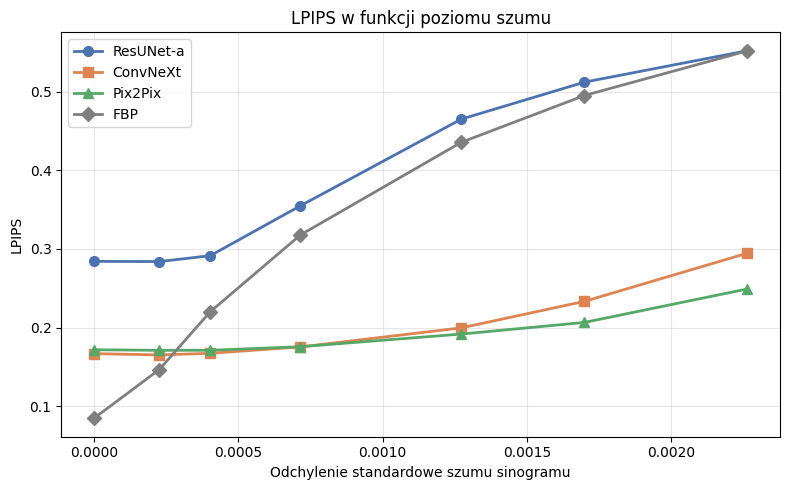

In [7]:
metrics = ["MSE", "SSIM", "PSNR", "Correlation", "LPIPS"]

for metric in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, data in models.items():
        ax.plot(
            noise_std,
            data[metric],
            label=name,
            linewidth=2,
            markersize=7,
            **styles[name],
        )
    ax.set_xlabel("Odchylenie standardowe szumu sinogramu")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} w funkcji poziomu szumu")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

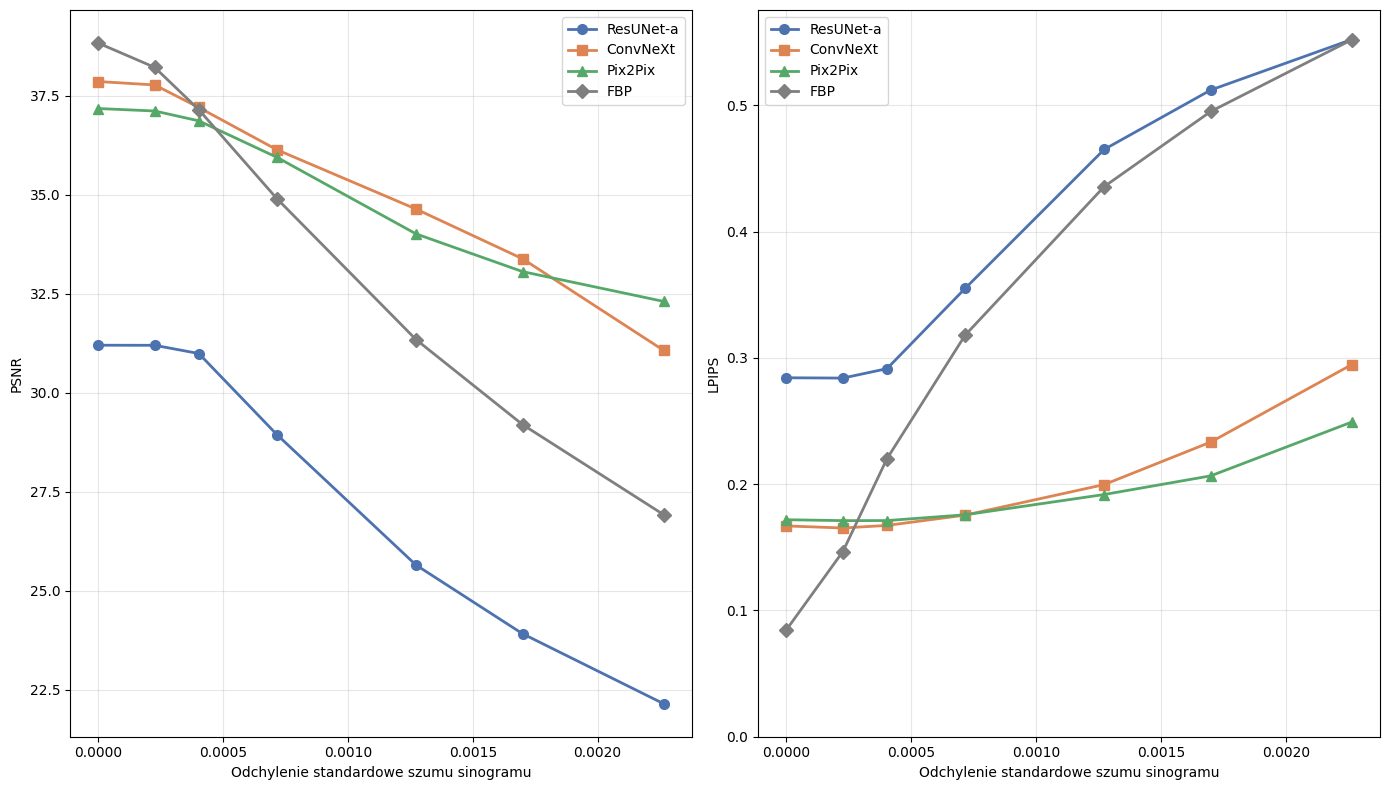

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, metric in zip(axes, ["PSNR", "LPIPS"]):
    for name, data in models.items():
        ax.plot(
            noise_std,
            data[metric],
            label=name,
            linewidth=2,
            markersize=7,
            **styles[name],
        )
    ax.set_xlabel("Odchylenie standardowe szumu sinogramu")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[1].set_ylim(bottom=0)

fig.tight_layout()
plt.show()